# **Titanic**: **Итоговый отчет**

В этом ноутбуке представлены все этапы решения задачи Kaggle `Titanic – Machine Learning from Disaster`: от первоначального анализа данных и проверки гипотез до обучения и сравнения ML и DL моделей.

В обучающем датасете Kaggle предоставляет следующие ключевые поля:

- `PassengerId` — уникальный идентификатор пассажира

- `Survived` — *****целевая переменная***** (0 — не выжил, 1 — выжил)

- `Pclass` — класс билета (1, 2, 3)

- `Name` — ФИО пассажира

- `Sex` — пол

- `Age` — возраст

- `SibSp` — число братьев/сестер/супругов на борту

- `Parch` — число родителей/детей на борту

- `Ticket` — номер билета

- `Fare` — стоимость проезда

- `Cabin` — номер каюты

- `Embarked` — порт посадки (C, Q, S)

## 1. Загрузка и первичный анализ данных

In [2]:
%load_ext autoreload
%autoreload 2
%cd ..

import src.config as cfg
import src.data as data
import src.features as features
import src.feature_search as fs
import src.openfe_stage as ofe_stage
import src.modeling as modeling
import src.evaluate as evaluate
import src.tuning as tuning
import src.profiling as prf
import src.train_pipeline as trn

from pathlib import Path
import pandas as pd
import joblib

import warnings
warnings.filterwarnings("ignore")

C:\Users\Barenin Vitalii\PycharmProjects\kaggle-titanic


В рамках решения задачи итогового проекта было решено разделить логику по различным модулям, для удобства работы и воспроизводимости. В файле конфигурации находятся настраиваемые параметры, модуль `data`  содержит функции для загрузки и сохранения данных, модуль `profiling` содержит функции для анализа и визуализации данных.

In [3]:
df = data.load_train()

Визуальный анализ значений признаков.

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


В модуле `profiling` содержится класс `DataProfiler`, который хранит в себе ссылку на исходный датасет, мета информацию о признаках и целевой переменной, а также множество функций позволяющих выполнить `EDA`.

In [5]:
dp = prf.DataProfiler(df, target=cfg.TARGET_COL)

In [6]:
dp.overview()

,dtype,logical_type,is_target,n_missing,pct_missing,n_unique,pct_unique
column,,,,,,,
PassengerId,int64,numeric,False,0,0.00,891,100.00
Survived,int64,categorical,True,0,0.00,2,0.22
Pclass,int64,numeric,False,0,0.00,3,0.34
Name,str,high_cardinality,False,0,0.00,891,100.00
Sex,str,categorical,False,0,0.00,2,0.22
Age,float64,numeric,False,177,19.87,88,9.88
SibSp,int64,numeric,False,0,0.00,7,0.79
Parch,int64,numeric,False,0,0.00,7,0.79
Ticket,str,high_cardinality,False,0,0.00,681,76.43


In [7]:
dp.info_summary()['duplicated_rows']

0

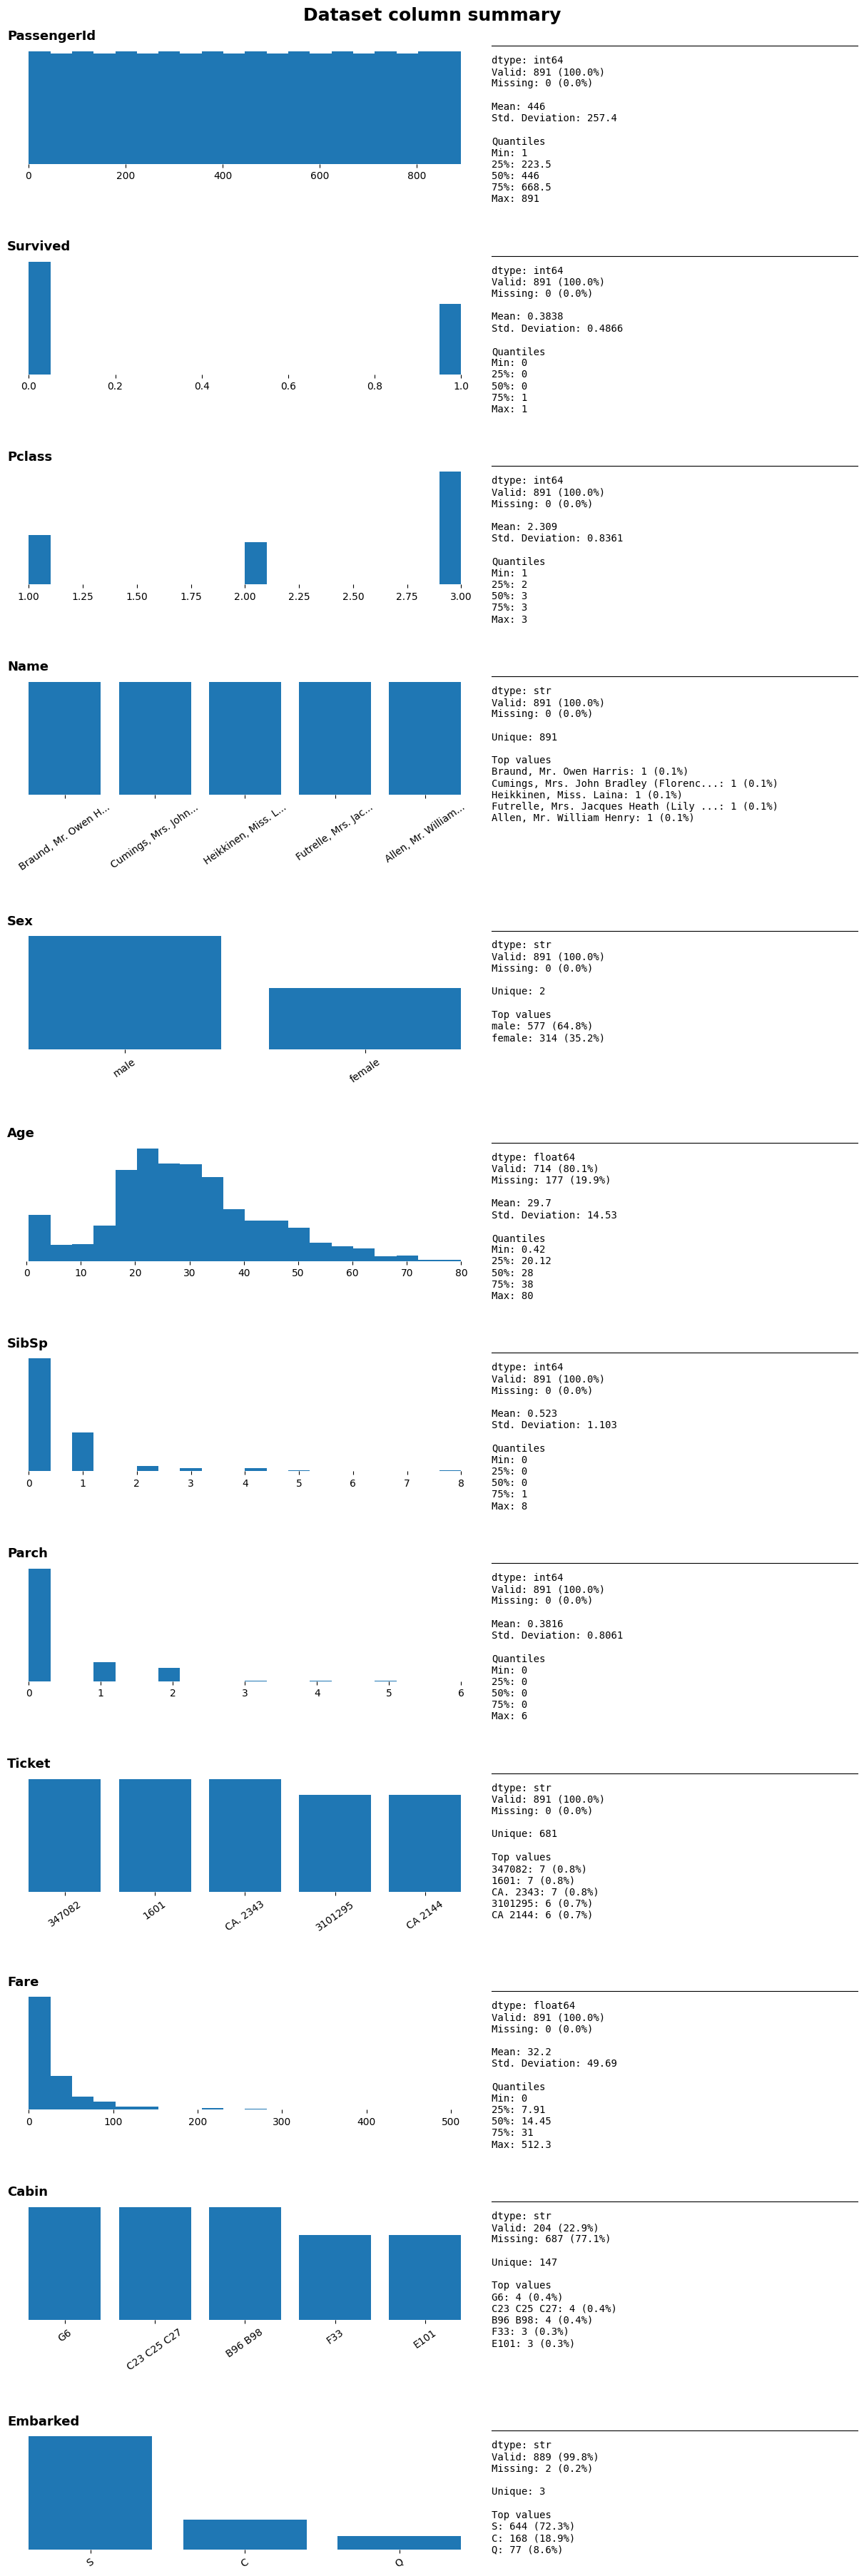

In [8]:
dp.dataframe_summary_plot(feature_type='all')

Уже по полученной информации можно сделать вывод, что:
- `PassengerId` не информативный порядковый параметр
-  `Survived` (target) имеет удовлетворительные пропорции
-  `Pclass` имеет 3 значения и является ранжирующим категориальным признаком
-  `Name` все уникальные значения, но присутствуют повторяющиеся префиксы Mr, Mrs и др.
-  `Sex` имеет перекос
-  `Age` гистрограмма напоминает нормальное распределение с полезными выбросами, присутствуют пропуски
-  `SibSp` и `Parch` числовые признаки, который можно объединить в один, посчитав общее количество родственников на корабле
-  `Ticket` имеет повторяющиеся значения, что говорит о выдаче билета на несколько человек (может быть семью)
-  `Fare` имеет явный левый перекос, а также экстремальные значения - нужно будет обрабатывать
-  `Cabin` есть повторяющиеся значения и очень много пропусков
-  `Embarked` 3 порта, 2 пропущенных  значения

Датасет маленький, всего 891 запись, поэтому данными нужно дорожить, а количество признаков держать небольшим, чтобы минимизировать переобучение.

Полезно посмотреть на тренировочный датасет, чтобы понять его возможные аномамлии.

In [9]:
df_test = data.load_test()

In [10]:
dp_test = prf.DataProfiler(df_test)
dp_test.overview()

,dtype,logical_type,is_target,n_missing,pct_missing,n_unique,pct_unique
column,,,,,,,
PassengerId,int64,numeric,False,0,0.00,418,100.00
Pclass,int64,numeric,False,0,0.00,3,0.72
Name,str,high_cardinality,False,0,0.00,418,100.00
Sex,str,categorical,False,0,0.00,2,0.48
Age,float64,numeric,False,86,20.57,79,18.90
SibSp,int64,numeric,False,0,0.00,7,1.67
Parch,int64,numeric,False,0,0.00,8,1.91
Ticket,str,high_cardinality,False,0,0.00,363,86.84
Fare,float64,numeric,False,1,0.24,169,40.43


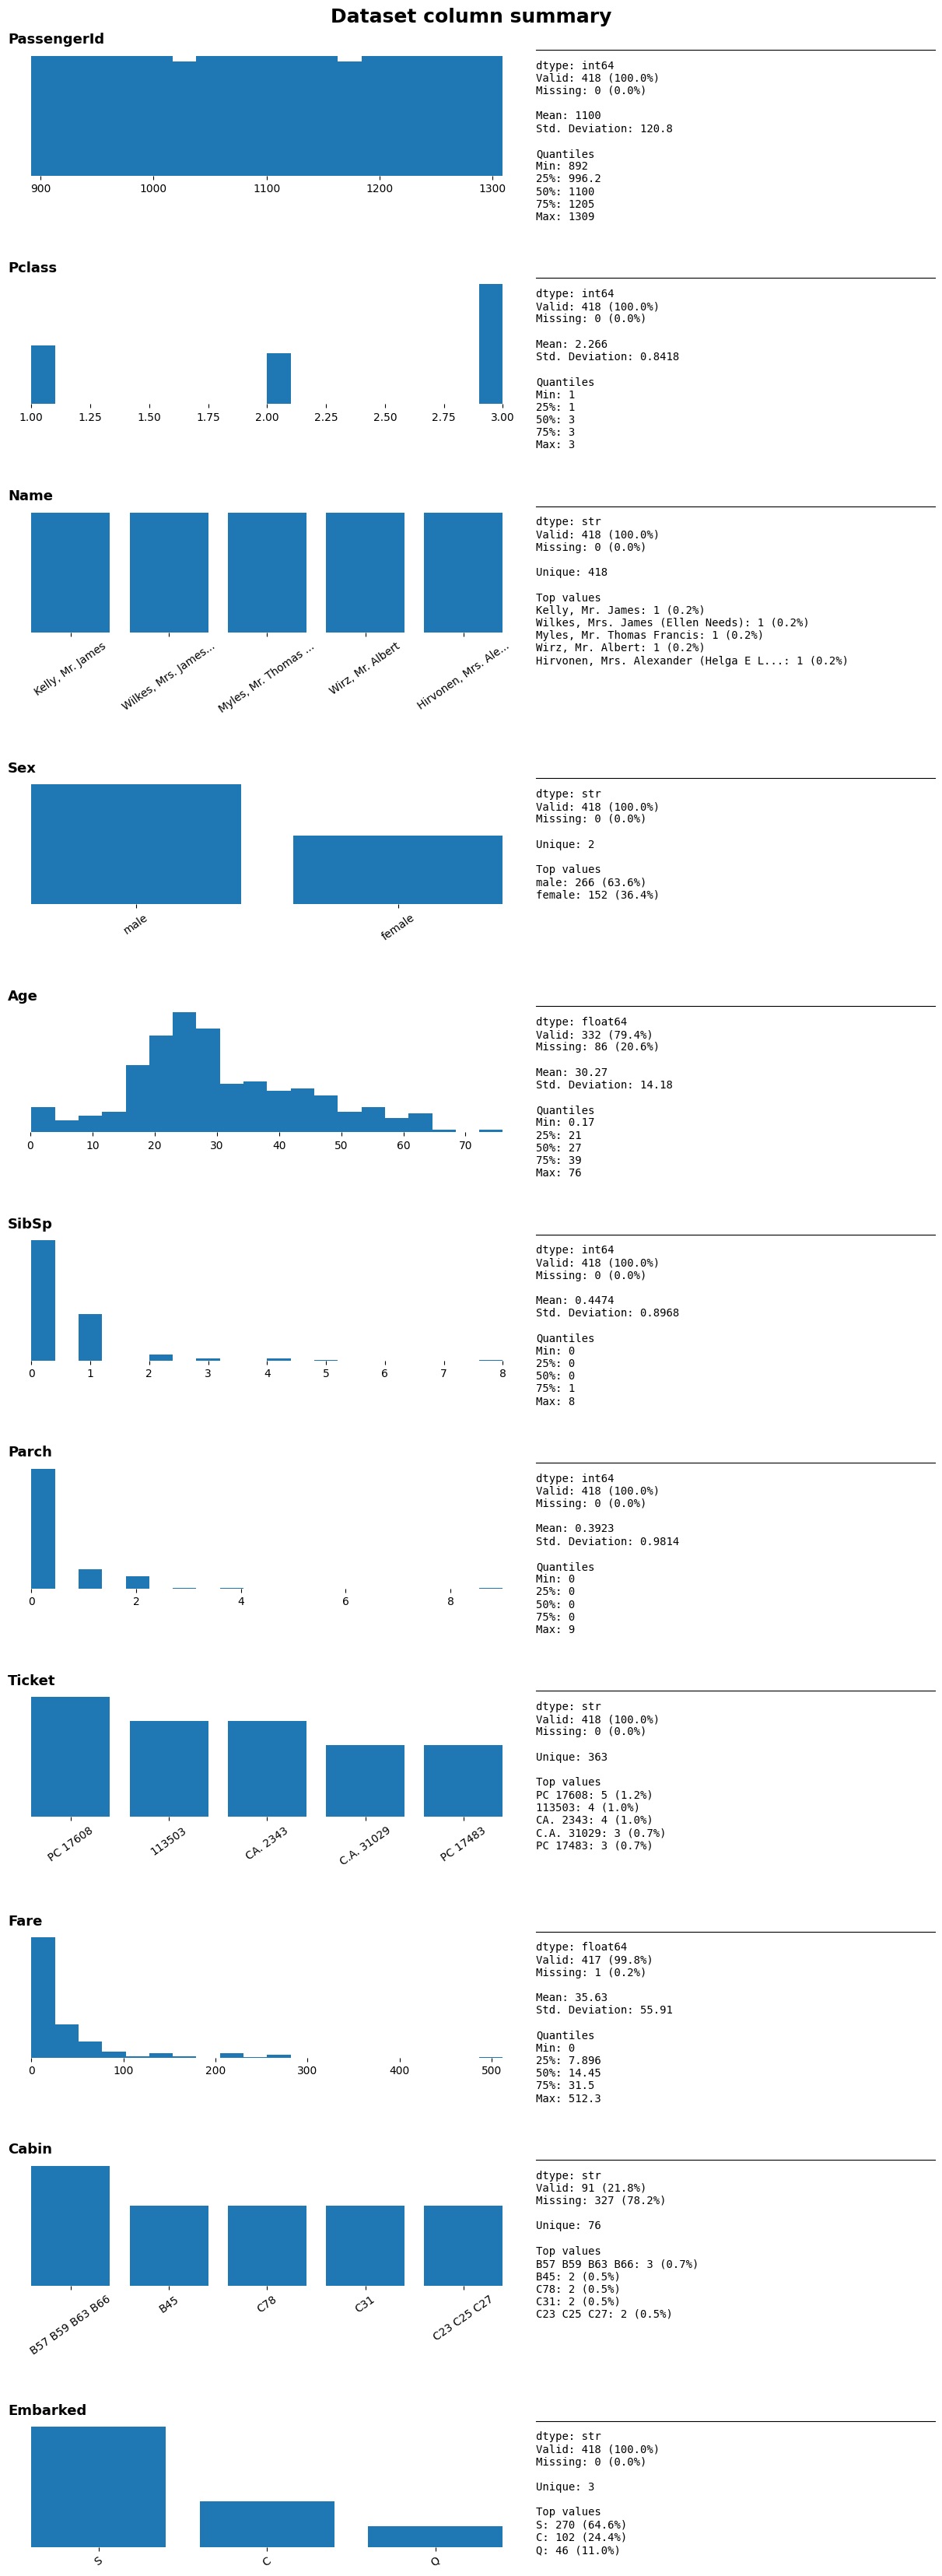

In [11]:
dp_test.dataframe_summary_plot(feature_type='all')

Картина похожа, из отличий присутствует один пропуск признака `Fare`

Полезно посмотреть на зависимость целевой переменной от признаков.

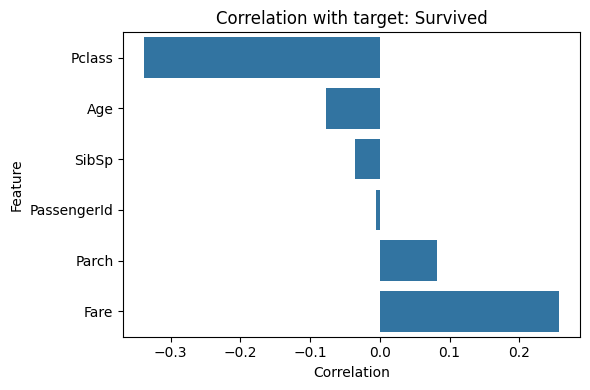

In [12]:
dp.plot_target_correlation()

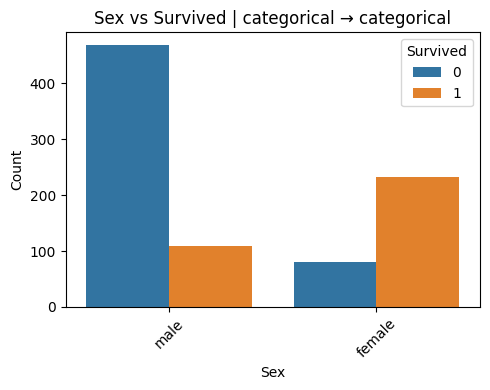

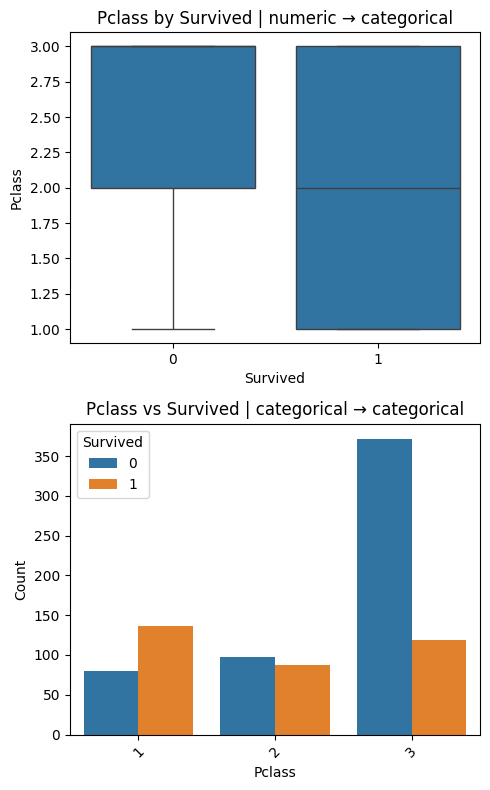

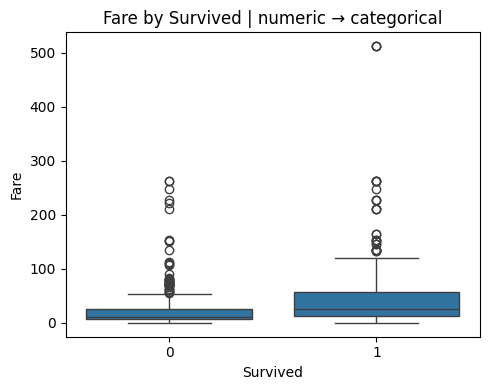

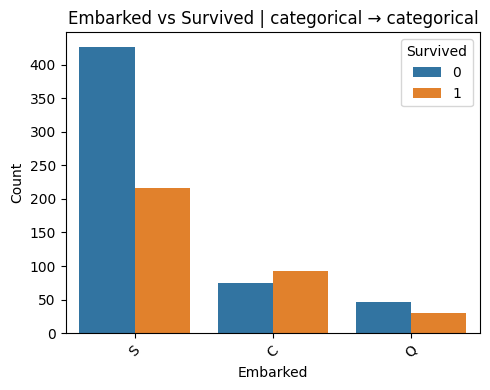

In [13]:
dp.plot_feature_vs_target("Sex", figsize_per_plot=(5, 4))
dp.plot_feature_vs_target("Pclass", figsize_per_plot=(5, 4))
dp.plot_feature_vs_target("Fare", figsize_per_plot=(5, 4))
dp.plot_feature_vs_target("Embarked", figsize_per_plot=(5, 4))

Как видно, на выживаемость сильно влияет `Pclass` и `Fare`. Больше выживших среди женщин, а также среди тех, кто имеет билеты первого класса, кто имеет порт посадки C

Основные сигналы от данных получны. Чтобы начать тестировать гипотезы построю baseline с моделью логистической регрессии `LogisticRegression` стандартными обработчиками данных `SimpleImputer`, `StandardScaler` объединенными в pipeline.

`SimpleImputer` для числовых признаков по умолчанию будет заполнять пропуски ***медианой***, а для категориальных самым часто встречающимся значением.

Логика препроцессинга объединена в функцию  `build_preprocessor` модуля `modeling`. Фабрика `build_model` возвращает модель обернутую в pipeline. Параметр `transform_off` отключает трансформации `TitanicFeaturesTransformer` в pipeline, чисто в деманстрационных целях.

In [14]:
X_raw = df.drop(columns=[cfg.TARGET_COL])
y = df[cfg.TARGET_COL]

model = modeling.build_model('logreg', X_raw, transform_off=True)

В модуль `evaluate` вынесена логика обучения модели с использованием `StratifiedKFold` и `cross_val_score`. Для воспроизводимости в файле конфигурации зафиксирован `SEED` и `DEFAULT_LOGREG_PARAMS`.

In [15]:
mean, std, scores = evaluate.cv_scores(model, X_raw, y)
print(f"CV {'logreg'}: mean={mean} std={std}")

CV logreg: mean=0.8069612704789403 std=0.0332360185803288


Первым делом обработаем существующие признаки:
- Обработаем выбросы и изменим распределение `Fare`
- Удалим `PassengerId`
- Трансформируем признак `Sex` в значения 0 и 1

Все трансформации с датасетом `Titanic` вынесены в отдельный класс `TitanicFeatures`. Комплексно они применяються в методе `transform`, а пока будут применяться по отдельности.

In [16]:
fe = features.TitanicFeatures()
exp_X = X_raw.copy()

# --- Fare -----------------------------------------------------
exp_X = fe._transform_fare_log(exp_X)

# --- PassengerId -----------------------------------------------------
exp_X = fe._drop_noise_features(exp_X, ['PassengerId'])

# --- Sex -----------------------------------------------------
exp_X = fe._encode_sex(exp_X)

In [17]:
exp_X.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,2.110213,NaN,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,4.280593,C85,C
2,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,2.188856,NaN,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,3.990834,C123,S
4,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,2.202765,NaN,S


In [18]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8092084614901763 std=0.03174426003933799


После преобразования признака `Sex` в число, можно посмотреть корреляцию с target

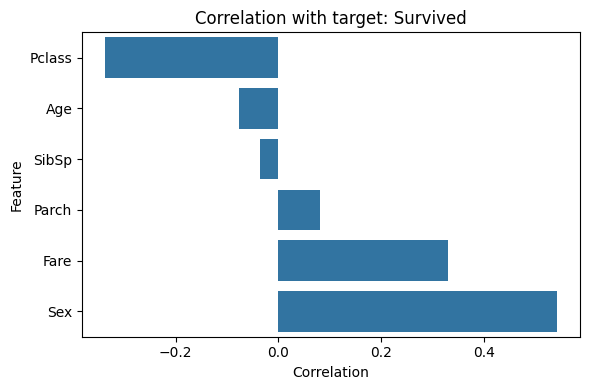

In [19]:
prf.DataProfiler(pd.concat([exp_X, y], axis=1), target=cfg.TARGET_COL).plot_target_correlation()

In [20]:
exp_X = fe._add_family_size(exp_X)

In [21]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8125729709371665 std=0.026942982676016646


In [22]:
exp_X = fe._add_ticket_group_size(exp_X)

In [23]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8148201619484026 std=0.025330659486197386


In [24]:
exp_X = fe._add_ticket_prefix(exp_X)

In [25]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8103257799259307 std=0.017898859717299213


In [26]:
exp_X = fe._extract_title(exp_X)

In [27]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8282593685267716 std=0.012885694630555573


In [28]:
exp_X = fe._add_cabin_deck(exp_X)

In [29]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8293829640323895 std=0.012870907900673094


Из распределения данных было замечено, что женщины выживают чаще чем погибают, также на выживаемость влияет класс билета. Поробуем проанализировать и составить комбинированный признак.

In [30]:
prf.DataProfiler(pd.concat([exp_X, y], axis=1), target=cfg.TARGET_COL).crosstab(
    ["Sex", "Pclass"], "Survived"
)

Survived           0         1
Sex Pclass                    
0   1       0.631148  0.368852
    2       0.842593  0.157407
    3       0.864553  0.135447
1   1       0.031915  0.968085
    2       0.078947  0.921053
    3       0.500000  0.500000

In [31]:
exp_X = fe._add_pclass_sex_feature(exp_X)

In [32]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8361182599962337 std=0.01909227939880155


Для линейных моделей непрерывные числовые величины лучше разбивать на диапазоны. Проанализируем на какие интервалы информативнее будет разбить.

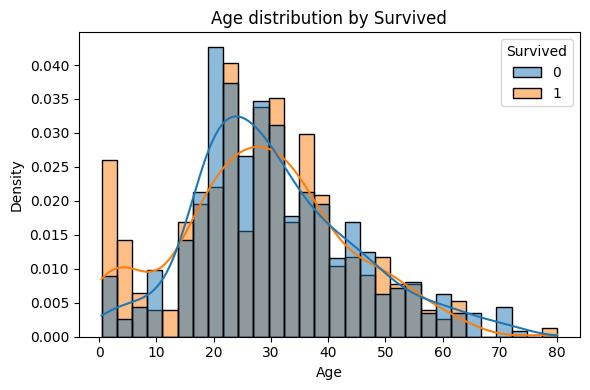

In [33]:
prf.DataProfiler(pd.concat([exp_X, y], axis=1), target=cfg.TARGET_COL).plot_feature_distribution("Age")

Исходя из графика выбраны следующие интервалы: `bins=[0, 12, 18, 40, 60, 100]`

In [34]:
exp_X = fe._bin_age_feature(exp_X)

In [35]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8394890465130876 std=0.021016370465164826


Для `Fare` аналогично, разобьем на 4 группы

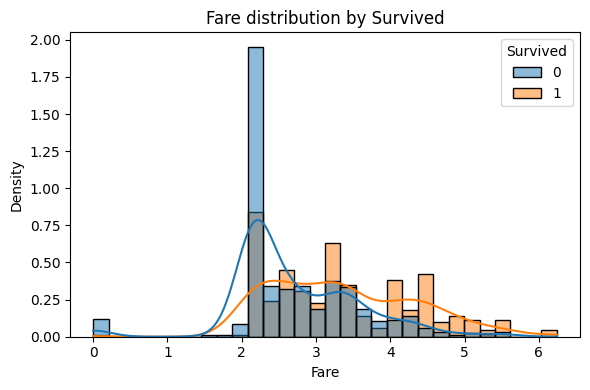

In [36]:
prf.DataProfiler(pd.concat([exp_X, y], axis=1), target=cfg.TARGET_COL).plot_feature_distribution("Fare")

In [37]:
exp_X = fe._bin_fare_feature(exp_X)

In [38]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8406063649488418 std=0.021926718811339924


In [39]:
exp_X.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,familysize,isalone,ticketgroupsize,TicketPrefix,Title,CabinDeck,Pclass_Sex,Age_bin,Fare_bin
0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,2.110213,NaN,S,2,0,1,A,Mr,NaN,0,2.0,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,4.280593,C85,C,2,0,1,PC,Mrs,C,1,2.0,3
2,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,2.188856,NaN,S,1,1,1,STON O,Miss,NaN,3,2.0,1
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,3.990834,C123,S,2,0,2,NONE,Mrs,C,1,2.0,3
4,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,2.202765,NaN,S,1,1,1,NONE,Mr,NaN,0,2.0,1


Экспериментальным образом доказываем, что разбитие числовых признаков на диапазоны лучшим образом влияет на работу линейной модели.

In [40]:
exp_X = fe._drop_noise_features(exp_X, ['Age'])
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8383654510074697 std=0.02184956864025592


Если удалить `Age_bin` CV logreg: mean=0.8361370912058252 std=0.016453252644067606

In [41]:
exp_X = fe._drop_noise_features(exp_X, ['Fare'])
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8394953235829515 std=0.024320182962963184


Если удалить `Fare_bin`
CV logreg: mean=0.8350009415604795 std=0.016654669254838217

Удалим признаки которые использовались для создания новых, чтобы избежать мультиколенеарности и переобучения.

In [42]:
drop_cols_for_logreg = ["Name", "Ticket", "Cabin", "SibSp", "Parch"]
exp_X = fe._drop_noise_features(exp_X, drop_cols_for_logreg)

In [43]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8316238779737619 std=0.01997013449142618


`std` уменьшилось, поэтому не такая уж печальная картина

Перед тем как перейти в методам оптимизации нахождения комбинаций новых фичей, оценим полезность уже существующих и удлаим лишние. Для этого будем использовать `mutual_info_classif`, `permutation_importance` библиотеки `sklearn`, а так же реальный вклад в score модели.

In [44]:
prf.DataProfiler(pd.concat([exp_X, y], axis=1), target=cfg.TARGET_COL).correlation_matrix(include_target=False)

,Pclass,Sex,familysize,isalone,ticketgroupsize,Pclass_Sex,Age_bin,Fare_bin
Pclass,1.000000,-0.131900,0.065997,0.135207,-0.002633,0.150380,-0.299149,-0.634271
Sex,-0.131900,1.000000,0.200988,-0.303646,0.154748,0.897070,-0.117676,0.243613
familysize,0.065997,0.200988,1.000000,-0.690922,0.748487,0.229815,-0.409513,0.465396
isalone,0.135207,-0.303646,-0.690922,1.000000,-0.458739,-0.260551,0.285103,-0.560279
ticketgroupsize,-0.002633,0.154748,0.748487,-0.458739,1.000000,0.139780,-0.354690,0.535210
Pclass_Sex,0.150380,0.897070,0.229815,-0.260551,0.139780,1.000000,-0.202034,0.054939
Age_bin,-0.299149,-0.117676,-0.409513,0.285103,-0.354690,-0.202034,1.000000,-0.025735
Fare_bin,-0.634271,0.243613,0.465396,-0.560279,0.535210,0.054939,-0.025735,1.000000


In [45]:
prof = prf.DataProfiler(pd.concat([exp_X, y], axis=1), target="Survived")

rep = prof.feature_report(modeling.build_model, exp_X, y, X_val=exp_X, y_val=y, transform_off=True)
rep["mutual_info"]

ticketgroupsize    0.194278
Age_bin            0.172785
Sex                0.150870
isalone            0.057587
Fare_bin           0.056866
Pclass             0.052016
Embarked           0.047781
Title              0.046180
Pclass_Sex         0.034877
CabinDeck          0.014233
TicketPrefix       0.008566
familysize         0.003219
dtype: float64

In [46]:
rep["ablation"]

Title              0.028059
Sex                0.008982
Pclass_Sex         0.005612
Age_bin            0.004494
ticketgroupsize    0.004488
familysize         0.004476
Embarked           0.003371
isalone            0.002241
Pclass            -0.001136
Fare_bin          -0.002247
CabinDeck         -0.002272
TicketPrefix      -0.003383
dtype: float64

In [47]:
rep["permutation"]

,importance_mean,importance_std
Sex,0.241414,0.015053
Title,0.087093,0.009065
familysize,0.047363,0.004595
Pclass_Sex,0.026038,0.004370
Age_bin,0.017172,0.006846
Embarked,0.017059,0.003284
CabinDeck,0.008418,0.003224
Pclass,0.008305,0.002978
isalone,0.001908,0.002842
TicketPrefix,0.000898,0.003284


Отрицательное значение признаков при `ablation`, говорит что они негативно влияют на общий score, но принимать решение будет на основе всех данных и интерпретируемости признаков. Признак `isalone` несмотря на то, что сильно коррелирует с `familysize`, может быть для модели более полезным и понятным. `TicketPrefix` слабый признак по всем параметрам. `Fare_bin` и `Pclass` имеют отрицательный ablation, но полезны поскольку сильно влияют на таргет. `ticketgroupsize` повторяет информацию `familysize` и `isalone`. `CabinDeck` очень шуиный - много пропусков, которые заполняются самым частным значением.

In [48]:
candidate_cols = [
    "TicketPrefix",
    "ticketgroupsize",
    "CabinDeck",
]
rmv_prof = prf.DataProfiler(pd.concat([exp_X, y], axis=1), target="Survived")

In [49]:
candidate_scores = rmv_prof.test_feature_removal_combinations(modeling.build_model, exp_X, y, candidate_cols, verbose=False)

In [50]:
candidate_scores.head(10)

,removed_features,n_removed,score_mean,score_std,delta_vs_baseline
0,"(TicketPrefix,)",1,0.835007,0.011692,0.003383
1,"(TicketPrefix, ticketgroupsize)",2,0.835007,0.015003,0.003383
2,"(CabinDeck,)",1,0.833896,0.014883,0.002272
3,"(ticketgroupsize, CabinDeck)",2,0.832779,0.015160,0.001155
4,(),0,0.831624,0.019970,0.000000
5,"(TicketPrefix, ticketgroupsize, CabinDeck)",3,0.830519,0.014036,-0.001105
6,"(TicketPrefix, CabinDeck)",2,0.828272,0.013233,-0.003352
7,"(ticketgroupsize,)",1,0.827136,0.018457,-0.004488


Посмотрим удаление какой комбинации улучшает score больше чем на std, чтобы убедиться что оно действительно полезно.

In [51]:
candidate_scores = candidate_scores.copy()

eps = 1e-8

candidate_scores["signal_to_noise"] = (
    candidate_scores["delta_vs_baseline"] /
    (candidate_scores["score_std"] + eps)
)

candidate_scores["delta_minus_std"] = (
    candidate_scores["delta_vs_baseline"] -
    candidate_scores["score_std"]
)

result = candidate_scores.sort_values(
    by="signal_to_noise",
    ascending=False
).reset_index(drop=True)

result.head(10)

,removed_features,n_removed,score_mean,score_std,delta_vs_baseline,signal_to_noise,delta_minus_std
0,"(TicketPrefix,)",1,0.835007,0.011692,0.003383,0.289365,-0.008309
1,"(TicketPrefix, ticketgroupsize)",2,0.835007,0.015003,0.003383,0.225515,-0.011619
2,"(CabinDeck,)",1,0.833896,0.014883,0.002272,0.152682,-0.012610
3,"(ticketgroupsize, CabinDeck)",2,0.832779,0.015160,0.001155,0.076187,-0.014005
4,(),0,0.831624,0.019970,0.000000,0.000000,-0.019970
5,"(TicketPrefix, ticketgroupsize, CabinDeck)",3,0.830519,0.014036,-0.001105,-0.078710,-0.015141
6,"(ticketgroupsize,)",1,0.827136,0.018457,-0.004488,-0.243172,-0.022945
7,"(TicketPrefix, CabinDeck)",2,0.828272,0.013233,-0.003352,-0.253311,-0.016585


Все признаки дают прирост в границах шума, поэтому оптимальной комбинацией будем считать уменьшение удаление всех признаков, так как уменьшается std и score не самый маленький.

In [52]:
noise_cols = ["TicketPrefix","ticketgroupsize", "CabinDeck"]
exp_X = fe._drop_noise_features(exp_X, noise_cols)

In [53]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.8305191136777352 std=0.014035912807016486


Так же вклад каждого признака можно оценить при помощи регуляризации `l1` и разных коэффициентах `C`, например при значении `0.1`, модель будет сильно штрафовать - занулять признаки.

In [54]:
params = {
    "max_iter":    2000,
    "C":           0.5,
    "l1_ratio":     1,
    "solver":      "liblinear",
    "random_state": cfg.SEED,
}

model = modeling.build_logreg_model(exp_X, params, transform_off=True)
model.fit(exp_X, y)

feature_names = model.named_steps["prep"].get_feature_names_out()

coefs = pd.Series(
    model.named_steps["model"].coef_[0],
    index=feature_names
)
print(coefs.sort_values())

num__Pclass_Sex           -1.010674
num__familysize           -0.829609
cat__Title_Mr             -0.576293
num__Pclass               -0.514566
cat__Embarked_S           -0.431402
num__Age_bin              -0.290828
num__isalone              -0.152974
cat__Title_Rare           -0.041294
cat__Title_the Countess    0.000000
cat__Title_Miss            0.000000
cat__Embarked_C            0.000000
cat__Embarked_Q            0.000000
cat__Title_Mrs             0.242189
num__Fare_bin              0.266547
cat__Title_Master          1.937207
num__Sex                   2.163136
dtype: float64


Теперь при помощи `OpenFE` прибегнем к автоматической генерации и отбору признаков.

In [55]:
stage = ofe_stage.OpenFEStage(model_name="logreg", **cfg.OPENFE_PARAMS)
X_ofe = stage.fit_transform(exp_X, y)

print("Base columns:    ", stage.base_columns_)
print("Selected OFE:    ", stage.selected_columns_)
print("All output cols: ", stage.get_feature_names_out())

The number of candidate features is 671
Start stage I selection.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:19<00:00,  4.90s/it]


435 same features have been deleted.
Meet early-stopping in successive feature-wise halving.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:09<00:00,  2.31s/it]


The number of remaining candidate features is 236
Start stage II selection.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:04<00:00,  1.12s/it]


Finish data processing.
[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2136
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 241

── Correlation filter ──
  CORR DROP autoFE_f_20                     |r|=0.9524  (with Fare_bin)
  CORR DROP autoFE_f_21                     |r|=0.9554  (with Pclass)

After corr filter: 30 → 28 OFE candidates

── Ablation (batch) ──
  n=  5  mean=0.8305  delta=+0.00112
  n= 10  mean=0.8316  delta=+0.00223
  n= 15  mean=0.8294  delta=+0.00000
  n= 20  mean=0.8294  delta=+0.00000
  n= 25  mean=0.8283  delta=-0.00113

── Greedy selection ──
  KEEP autoFE_f_0                      mean=0.83499  delta=+0.00560
  DROP autoFE_f_17                     mean=0

In [56]:
trn.quick_experiment(X_ofe, y, 'logreg', transform_off=True)

CV logreg: mean=0.8372418555018518 std=0.013963445965081032


In [57]:
registry = stage.build_feature_registry(X_ofe)
print(registry.sort_values(["selected", "greedy_delta"], ascending=[False, False]))

        column         operator                              formula  \
0   autoFE_f_0  CombineThenFreq  CombineThenFreq(isalone,Pclass_Sex)   
1   autoFE_f_9  GroupByThenRank      GroupByThenRank(Sex,Pclass_Sex)   
2  autoFE_f_15  GroupByThenRank      GroupByThenRank(Pclass,Age_bin)   

   selected  greedy_mean  greedy_std  greedy_delta  dropped_by_corr corr_with  \
0      True      0.83499     0.01381       0.00560            False      None   
1      True      0.83612     0.01460       0.00112            False      None   
2      True      0.83724     0.01396       0.00112            False      None   

  corr_value  
0       None  
1       None  
2       None  


`OpenFE` нагенерировала много признаков, однако прирост score у всех находится в границах шума - `std`. Чтобы не увеличивать количество признаков и не усложнять модель, не будем их применять.

Подберем гиперпараметры используя модуль `optuna`

In [58]:
best_model, study = tuning.tune_with_optuna("logreg", exp_X, y)
print(f"Optuna best score: {study.best_value}")
print(f"Best params: {study.best_trial.params}")

Optuna best score: 0.8316427091833531
Best params: {'model__C': 0.6288727650713798, 'model__solver': 'lbfgs'}


Чтобы поместить `TitanicFeatures` в pipeline построения модели, необходимо создать класс который наследуется от `BaseEstimator`, `TransformerMixin`.

```python
class TitanicFeaturesTransformer(
    TitanicFeatures, 
    BaseEstimator, 
    TransformerMixin
):
```

Весь pipeline уже создается внутри `build_model`, чтобы активировать трансформации, нужно передать параметр `transform_off=False`

In [59]:
trn.quick_experiment(exp_X, y, 'logreg', transform_off=True)

CV logreg: mean=0.830525390747599 std=0.013028260755140447


In [60]:
trn.quick_experiment(X_raw, y, 'logreg', transform_off=False)

CV logreg: mean=0.8316489862532169 std=0.011790385931292101


> Разница в score связана с тем, что при ручном feature engineering часть преобразований считалась на всём датасете до кросс-валидации, что даёт data leakage. Это `Fare_bin` и `Age_bin`.
>Вариант с `Pipeline` + `TitanicFeaturesTransformer` корректнее: все трансформации при CV только на train-фолде и затем применяются к validation-фолду, поэтому такая оценка честнее.

Посмотрим score на тесте через kaggle

In [62]:
df_test = data.load_test()
model_test = modeling.train_model("logreg")
modeling.predict_and_save_titanic(model_test, df_test, "submission")

Saved processed data to C:\Users\Barenin Vitalii\PycharmProjects\kaggle-titanic\data\processed\submission.csv


Public Score на Kaggle - 0.77990

### KNN

In [138]:
import importlib

importlib.reload(cfg)
importlib.reload(modeling)
importlib.reload(tuning)
importlib.reload(trn)

<module 'src.train_pipeline' from 'C:\\Users\\Barenin Vitalii\\PycharmProjects\\kaggle-titanic\\src\\train_pipeline.py'>

In [116]:
trn.quick_experiment(X_raw, y, 'knn', transform_off=False)

CV knn: mean=0.8237712635741637 std=0.028677369196683213


In [117]:
best_model, study = tuning.tune_with_optuna("knn", X_raw, y, transform_off=False)
print(f"Optuna best score: {study.best_value}")
print(f"Best params: {study.best_trial.params}")

Optuna best score: 0.8260310087251271
Best params: {'model__n_neighbors': 21, 'model__weights': 'distance', 'model__p': 2, 'model__leaf_size': 46}


In [118]:
params = {'n_neighbors': 21, 
          'weights': 'distance', 
          'p': 2, 
          'leaf_size': 46
         }

По умолчанию оставил параметр `metric` равным `minkowski`. Подбирать будем его по значению `p`

In [119]:
trn.quick_experiment(X_raw, y, 'knn', params=params, transform_off=False)

CV knn: mean=0.8260310087251271 std=0.02107418119675853


In [120]:
df_test = data.load_test()
model_test = modeling.train_model("knn", params)
modeling.predict_and_save_titanic(model_test, df_test, "submission_knn")

Saved processed data to C:\Users\Barenin Vitalii\PycharmProjects\kaggle-titanic\data\processed\submission_knn.csv


Public Score на Kaggle - 0.77033

## DecisionTreeClassifier

In [121]:
trn.quick_experiment(X_raw, y, 'tree', transform_off=False)

CV tree: mean=0.8091959073504489 std=0.015968483281636


In [122]:
best_model, study = tuning.tune_with_optuna("tree", X_raw, y, transform_off=False)
print(f"Optuna best score: {study.best_value}")
print(f"Best params: {study.best_trial.params}")

Optuna best score: 0.8305128366078713
Best params: {'model__criterion': 'entropy', 'model__max_depth': 9, 'model__min_samples_split': 30, 'model__min_samples_leaf': 12, 'model__max_features': 'sqrt', 'model__class_weight': None}


In [123]:
params_tree = {
    'criterion': 'entropy', 
    'max_depth': 9, 
    'min_samples_split': 30, 
    'min_samples_leaf': 12, 
    'max_features': 'sqrt', 
    'class_weight': None
         }

In [124]:
trn.quick_experiment(X_raw, y, 'tree', params=params_tree, transform_off=False)

CV tree: mean=0.8305128366078713 std=0.013177203853690258


In [125]:
df_test = data.load_test()
model_test = modeling.train_model("tree", params_tree)
modeling.predict_and_save_titanic(model_test, df_test, "submission_tree")

Saved processed data to C:\Users\Barenin Vitalii\PycharmProjects\kaggle-titanic\data\processed\submission_tree.csv


Public Score на Kaggle - 0.77511 - присутствует биндинг `Age` и `Fare`

Public Score на Kaggle - 0.76315 - отсутствует 

## Random Forest

In [114]:
trn.quick_experiment(X_raw, y, 'rf', transform_off=False)

CV rf: mean=0.8282656455966355 std=0.013768740941830457


In [115]:
best_model, study = tuning.tune_with_optuna("rf", X_raw, y, transform_off=False)
print(f"Optuna best score: {study.best_value}")
print(f"Best params: {study.best_trial.params}")

Optuna best score: 0.8350134957002071
Best params: {'model__n_estimators': 700, 'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4}


In [126]:
rf_params = {
    "n_estimators":    700,
    "criterion":       "gini",
    "max_depth":       4,
    "min_samples_split": 2,
    "min_samples_leaf":  4,
}

In [127]:
trn.quick_experiment(X_raw, y, 'rf', params=rf_params, transform_off=False)

CV rf: mean=0.8350134957002071 std=0.016542174094243987


In [128]:
df_test = data.load_test()
model_test = modeling.train_model("rf", rf_params)
modeling.predict_and_save_titanic(model_test, df_test, "submission_rf")

Saved processed data to C:\Users\Barenin Vitalii\PycharmProjects\kaggle-titanic\data\processed\submission_rf.csv


Public Score на Kaggle - 0.77751

## CatBoost

In [133]:
trn.quick_experiment(X_raw, y, 'cat', transform_off=False)

CV cat: mean=0.8271608813006088 std=0.0074338901391068175


In [139]:
best_model, study = tuning.tune_with_optuna("cat", X_raw, y, transform_off=False)
print(f"Optuna best score: {study.best_value}")
print(f"Best params: {study.best_trial.params}")

Optuna best score: 0.8383780051471973
Best params: {'model__iterations': 500, 'model__learning_rate': 0.01026525689012051, 'model__depth': 4, 'model__l2_leaf_reg': 3.324680480345779}


In [141]:
cat_params = {
    'iterations': 500, 
    'learning_rate': 0.01026525689012051, 
    'depth': 4, 
    'l2_leaf_reg': 3.324680480345779
}

In [142]:
trn.quick_experiment(X_raw, y, 'cat', params=cat_params,transform_off=False)

CV cat: mean=0.8383780051471973 std=0.0066803655201011156


In [144]:
df_test = data.load_test()
model_test = modeling.train_model("cat", cat_param)
modeling.predict_and_save_titanic(model_test, df_test, "submission_cat")

Saved processed data to C:\Users\Barenin Vitalii\PycharmProjects\kaggle-titanic\data\processed\submission_cat.csv


## XGBoost

In [145]:
trn.quick_experiment(X_raw, y, 'xgb', transform_off=False)

CV xgb: mean=0.8294206264515724 std=0.01013372616133543


## LightGBM

In [146]:
trn.quick_experiment(X_raw, y, 'lgbm', transform_off=False)

CV lgbm: mean=0.8204506936162199 std=0.014306203765697956


## Deep Neural Network (DNN)

In [223]:
X_ofe.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Pclass           891 non-null    int64  
 1   Sex              891 non-null    int64  
 2   Embarked         889 non-null    str    
 3   familysize       891 non-null    int64  
 4   isalone          891 non-null    int64  
 5   ticketgroupsize  891 non-null    int64  
 6   Title            891 non-null    str    
 7   CabinDeck        204 non-null    str    
 8   Pclass_Sex       891 non-null    int64  
 9   Age_bin          714 non-null    float64
 10  Fare_bin         891 non-null    int64  
 11  autoFE_f_1       891 non-null    float64
 12  autoFE_f_19      891 non-null    float64
 13  autoFE_f_20      889 non-null    float64
dtypes: float64(4), int64(7), str(3)
memory usage: 101.3 KB


In [225]:
exp_X.columns

Index(['Pclass', 'Sex', 'Embarked', 'familysize', 'isalone', 'ticketgroupsize',
       'Title', 'CabinDeck', 'Pclass_Sex', 'Age_bin', 'Fare_bin'],
      dtype='str')

In [103]:
prof = prf.DataProfiler(pd.concat([exp_X, y], axis=1), target="Survived")

rep = prof.feature_report(modeling.build_model, exp_X, y, X_val=exp_X, y_val=y, transform_off=True)
rep["mutual_info"]

ticketgroupsize    0.194278
Age_bin            0.172785
Sex                0.150870
isalone            0.057587
Fare_bin           0.056866
Pclass             0.052016
Embarked           0.047781
CabinDeck          0.046180
Pclass_Sex         0.037987
Title              0.008566
familysize         0.003219
dtype: float64

In [104]:
rep["ablation"]

Title              0.031429
Embarked           0.008989
Sex                0.007865
familysize         0.006748
Age_bin            0.006742
Pclass_Sex         0.006742
CabinDeck          0.006735
isalone            0.000013
Pclass             0.000006
ticketgroupsize    0.000000
Fare_bin           0.000000
dtype: float64

In [105]:
rep["permutation"]

,importance_mean,importance_std
Sex,0.241190,0.014825
Title,0.095398,0.010788
familysize,0.049719,0.003922
Pclass_Sex,0.027609,0.005411
Age_bin,0.019865,0.004736
Embarked,0.016386,0.003222
CabinDeck,0.012009,0.003216
Pclass,0.008979,0.003549
isalone,0.005724,0.003635
Fare_bin,0.002469,0.004040


In [116]:
params = {
    "max_iter":    2000,
    "C":           0.5,
    "l1_ratio":     1,
    "solver":      "liblinear",
    "random_state": cfg.SEED,
}

model = modeling.build_logreg_model(exp_X, params, transform_off=True)
model.fit(exp_X, y)

feature_names = model.named_steps["prep"].get_feature_names_out()

coefs = pd.Series(
    model.named_steps["model"].coef_[0],
    index=feature_names
)
print(coefs.sort_values())

num__Pclass_Sex           -0.973523
num__familysize           -0.811058
cat__CabinDeck_C          -0.523137
num__Pclass               -0.431602
cat__Embarked_S           -0.325473
num__Age_bin              -0.299761
num__isalone              -0.140577
cat__Title_Mr             -0.084617
cat__Title_Rare            0.000000
cat__Embarked_Q            0.000000
cat__Title_Miss            0.000000
cat__CabinDeck_G           0.000000
cat__CabinDeck_B           0.000000
cat__CabinDeck_A           0.000000
cat__Title_the Countess    0.000000
num__ticketgroupsize       0.000000
cat__CabinDeck_T           0.000000
cat__CabinDeck_F           0.000000
cat__CabinDeck_D           0.003006
cat__Embarked_C            0.048771
num__Fare_bin              0.241609
cat__Title_Mrs             0.293879
cat__CabinDeck_E           0.383219
num__Sex                   2.347222
cat__Title_Master          2.407665
dtype: float64


Бесполезными признаками оказались Pclass_Sex, ticketgroupsize

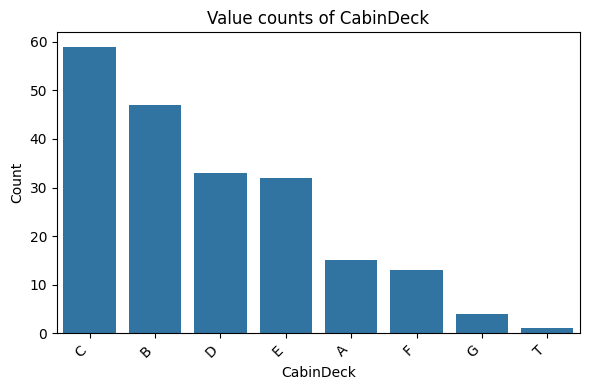

In [111]:
prof.plot_distribution('CabinDeck')

In [229]:

fe_tr = modeling.TitanicFeaturesTransformer(
    use_log_fare = True,
    use_age_bins = True,
    use_fare_bins = True,
    use_pclass_sex = True,
    model_type = "linear"
)
X_tr = fe_tr.fit_transform(X_raw)
X_tr.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'familysize',
       'Age_bin', 'Fare_bin', 'Pclass_Sex'],
      dtype='str')

In [ ]:
"Age", "Fare", 

In [103]:
exp_X.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Pclass           891 non-null    int64  
 1   Name             891 non-null    str    
 2   Sex              891 non-null    int64  
 3   Age              714 non-null    float64
 4   SibSp            891 non-null    int64  
 5   Parch            891 non-null    int64  
 6   Ticket           891 non-null    str    
 7   Fare             891 non-null    float64
 8   Cabin            204 non-null    str    
 9   Embarked         889 non-null    str    
 10  familysize       891 non-null    int64  
 11  isalone          891 non-null    int64  
 12  ticketgroupsize  891 non-null    int64  
 13  TicketPrefix     891 non-null    str    
dtypes: float64(2), int64(7), str(5)
memory usage: 132.1 KB


In [97]:
ticket_analysis = exp_X.groupby("Ticket").agg(
    group_size=("Ticket", "size"),
    mean_family_size=("familysize", "mean"),
    unique_family_sizes=("familysize", "nunique")
)

ticket_analysis.head(10)

,group_size,mean_family_size,unique_family_sizes
Ticket,,,
110152,3,1.0,1
110413,3,3.0,1
110465,2,1.0,1
110564,1,1.0,1
110813,1,2.0,1
111240,1,1.0,1
111320,1,1.0,1
111361,2,2.0,1
111369,1,1.0,1


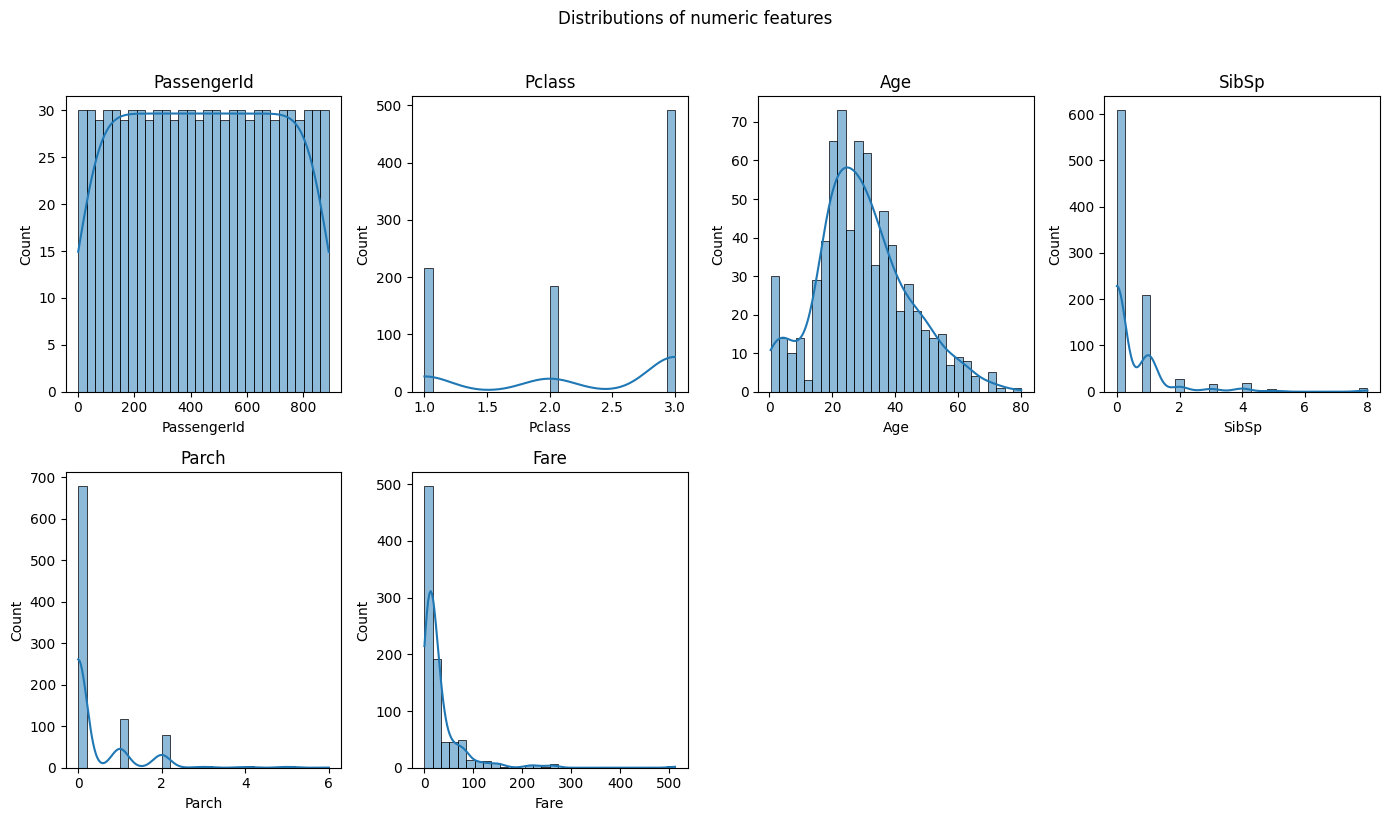

In [28]:
dp.plot_all_distributions()

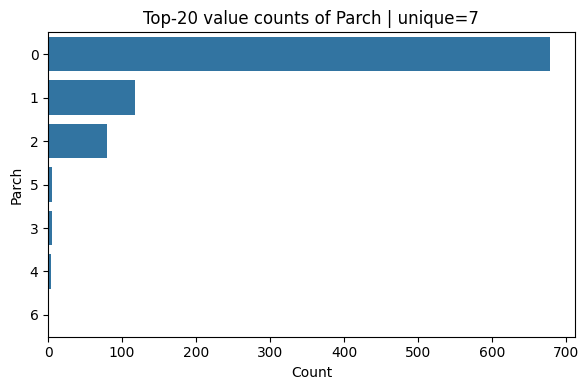

In [33]:
dp.plot_value_counts('Parch')

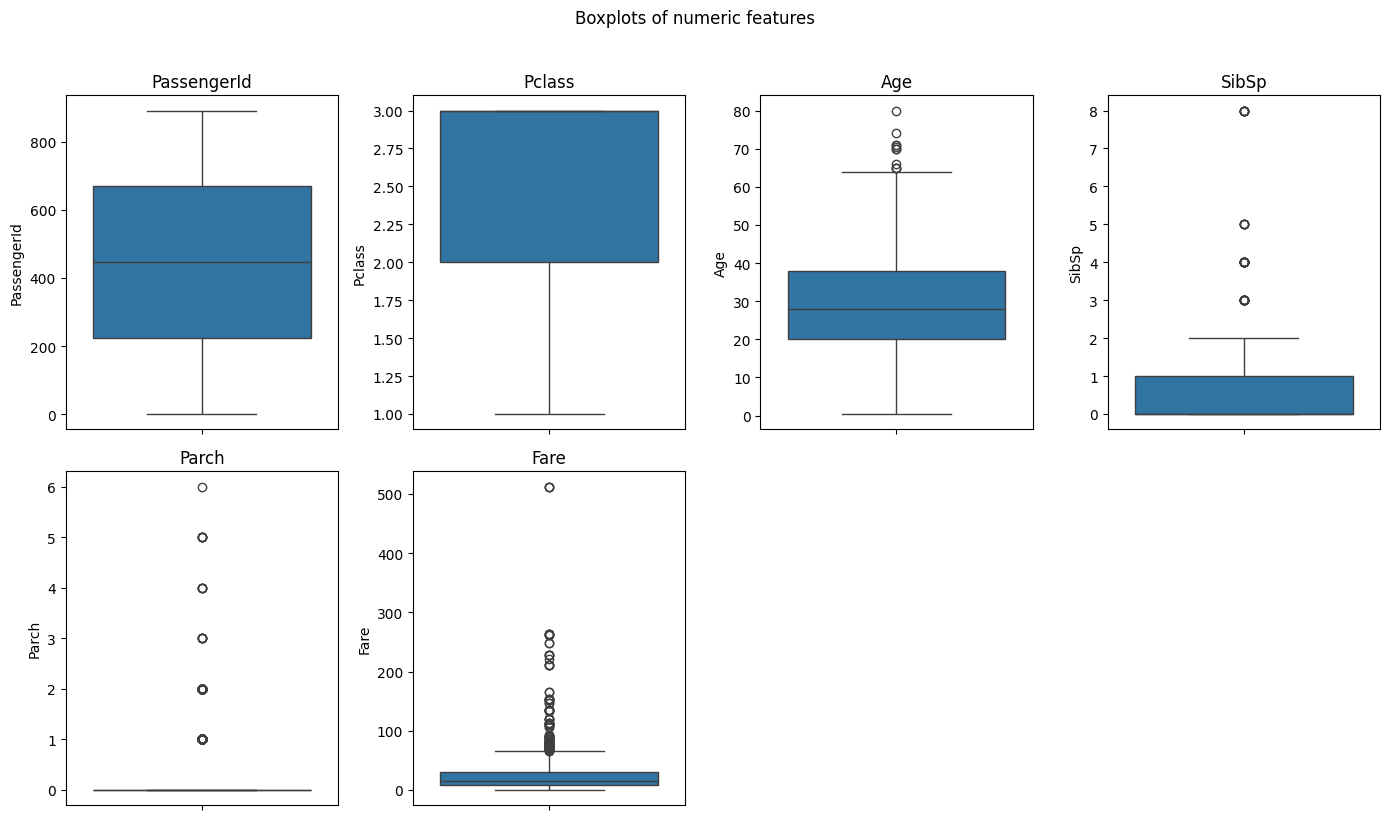

In [35]:
dp.plot_all_boxplots()

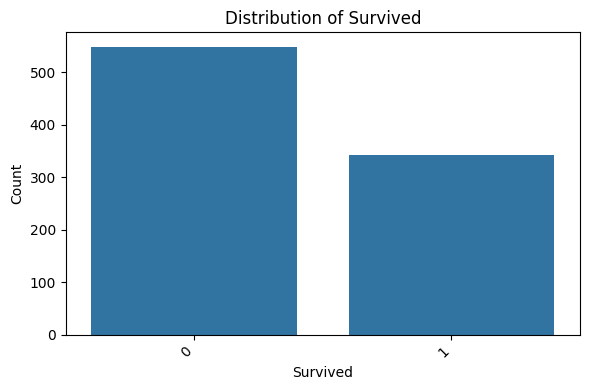

In [39]:
dp.plot_target_distribution()

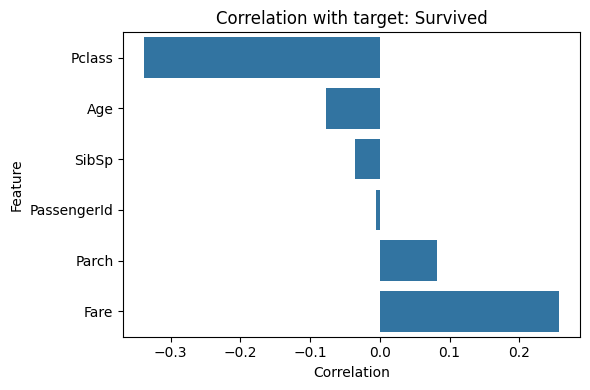

In [40]:
dp.plot_target_correlation()

In [44]:
sex_ct = dp.crosstab("Sex", cfg.TARGET_COL, normalize="index")
display(sex_ct)

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


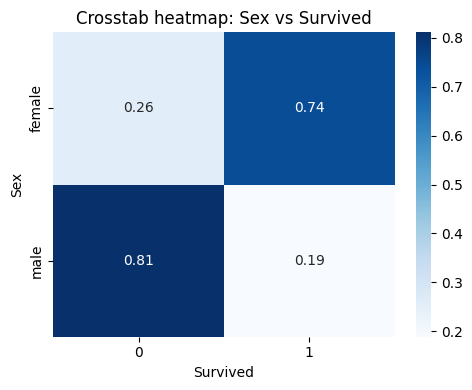

In [45]:
dp.plot_crosstab_heatmap("Sex", cfg.TARGET_COL, normalize="index", figsize=(5, 4))

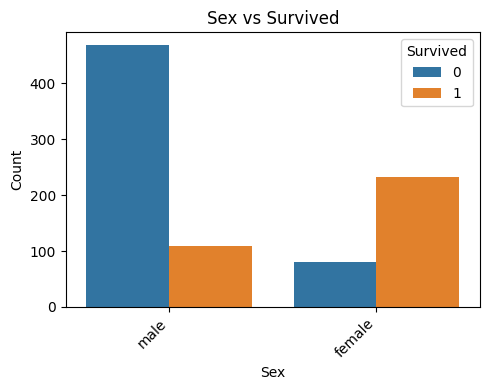

In [46]:
dp.plot_feature_vs_target("Sex", figsize=(5, 4))

In [47]:
dp.crosstab("Pclass", cfg.TARGET_COL, normalize="index")

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


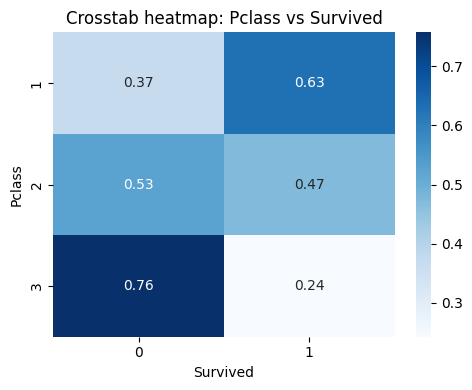

In [48]:
dp.plot_crosstab_heatmap("Pclass", cfg.TARGET_COL, normalize="index", figsize=(5, 4))

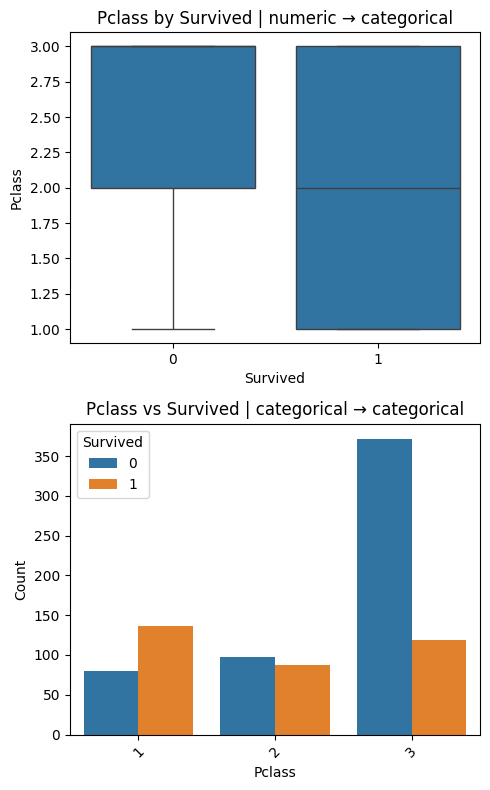

In [55]:
dp.plot_feature_vs_target("Pclass", figsize_per_plot=(5, 4))

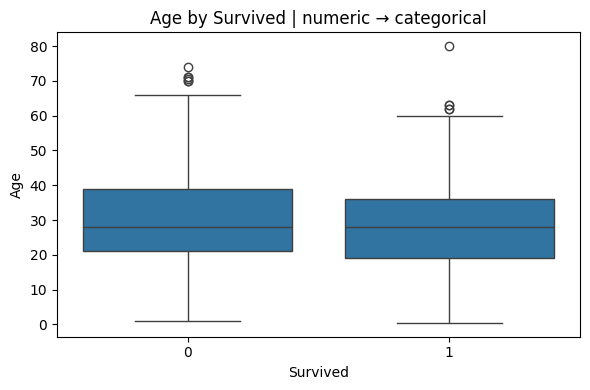

In [56]:
dp.plot_feature_vs_target("Age", figsize_per_plot=(6, 4))

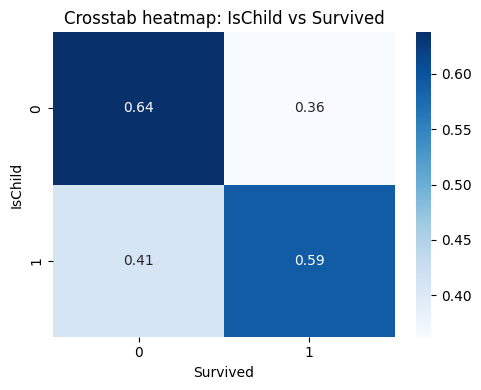

In [57]:
train_df = df.copy()
train_df["IsChild"] = (train_df["Age"] < 16).astype(int)
prof_child = prf.DataProfiler(train_df, target=cfg.TARGET_COL)

prof_child.plot_crosstab_heatmap("IsChild", cfg.TARGET_COL, normalize="index", figsize=(5, 4))

In [58]:
dp.crosstab("Embarked", cfg.TARGET_COL, normalize="index")

Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


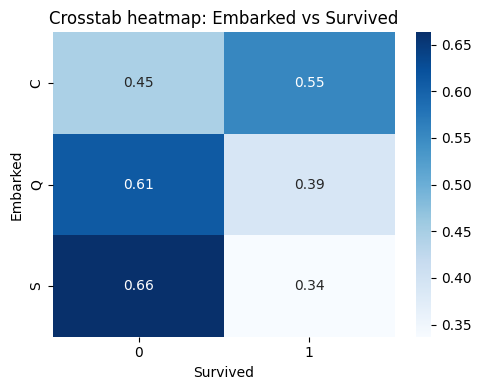

In [59]:
dp.plot_crosstab_heatmap("Embarked", cfg.TARGET_COL, normalize="index", figsize=(5, 4))

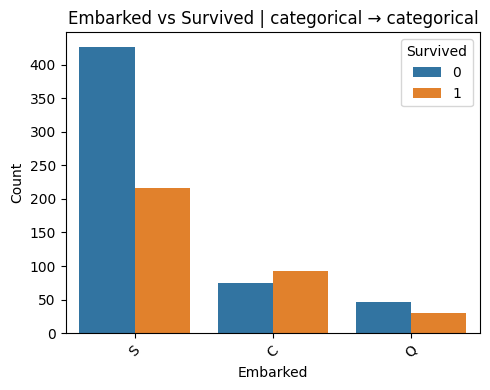

In [60]:
dp.plot_feature_vs_target("Embarked", figsize_per_plot=(5, 4))

In [61]:
tmp = df.copy()
tmp["familysize"] = tmp["SibSp"] + tmp["Parch"] + 1
tmp["isalone"] = (tmp["familysize"] == 1).astype(int)

In [62]:
prof_fam = prf.DataProfiler(tmp, target=cfg.TARGET_COL)

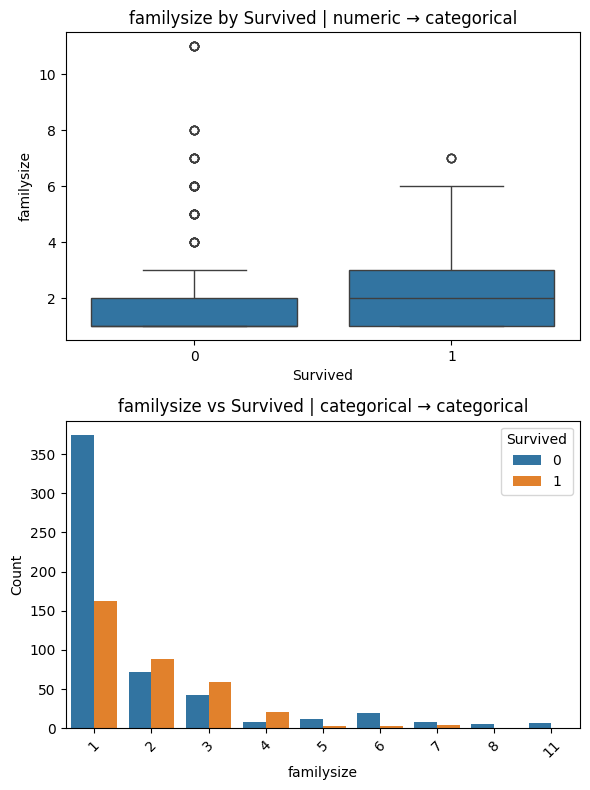

In [63]:
prof_fam.plot_feature_vs_target("familysize", figsize_per_plot=(6, 4))

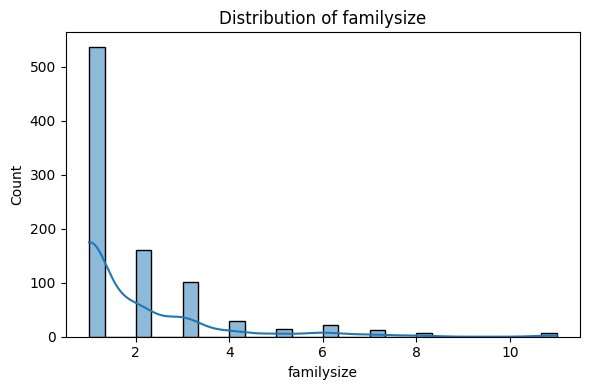

In [68]:
prof_fam.plot_distribution("familysize", figsize=(6, 4))

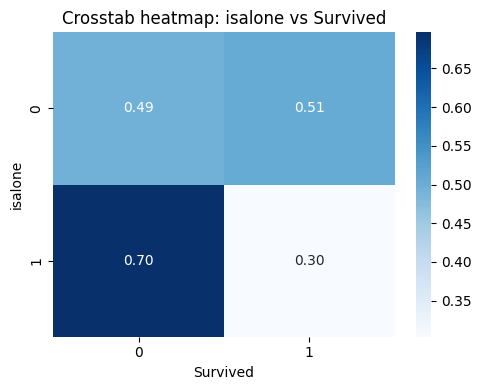

In [64]:
prof_fam.plot_crosstab_heatmap("isalone", cfg.TARGET_COL, normalize="index", figsize=(5, 4))

In [67]:
target_corr = dp.target_correlation_summary()
display(target_corr.sort_values("correlation_with_target", ascending=False))

,correlation_with_target
Fare,0.257307
Parch,0.081629
PassengerId,-0.005007
SibSp,-0.035322
Age,-0.077221
Pclass,-0.338481
